# 3D Crust Models

This notebook focuses on lunar crustal structure only.

It combines:
- the Kim et al. GRAIL crustal-thickness grid you downloaded
- lunar topography loaded with `pygmt.datasets.load_moon_relief`
- 3D and 2D crust plots
- a longitude cross-section with topography, true Moho, exaggerated Moho, and a core+magma schematic


In [44]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],

    "axes.titlesize": 18,     # subplot titles
    "axes.labelsize": 18,     # X/Y labels
    "xtick.labelsize": 18,    # x tick labels
    "ytick.labelsize": 18,    # y tick labels

    "axes.titleweight": "regular",
    "axes.labelweight": "regular",
})

In [45]:
# If needed, install the packages in this kernel first:
# %pip install numpy pandas matplotlib xarray scipy pygmt

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from IPython.display import display

try:
    import pygmt
except ModuleNotFoundError:
    pygmt = None
    print("`pygmt` is not installed in this kernel. Install it with `%pip install pygmt`. `load_moon_relief` also needs GMT available in the environment.")


## Configuration

The crustal-thickness grid is your local Kim et al. model. The topography is loaded programmatically from PyGMT.


In [46]:
GRAIL_GRID = Path("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/data/raw/thick-2-35.5-12-3400.txt")
OUTPUT_CSV = Path("/Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/grail_crust_thickness_table.csv")

SURFACE_RADIUS_KM = 1737.4
PLOT_STRIDE_3D = 10
PLOT_STRIDE_2D = 4
MOON_RELIEF_RESOLUTION = "10m"

CROSS_SECTION_LON_DEG = 3.6
TOPOGRAPHY_EXAGGERATION = 6.0
MOHO_EXAGGERATION = 6.0
CORE_RADIUS_KM = 350.0
MAGMA_INNER_FACTOR = 0.90
MAGMA_OUTER_FACTOR = 1.20
MAGMA_FADE_KM = 80.0
MAGMA_PIXELS = 500
MAGMA_RANDOM_SEED = 7


In [47]:
def _match_longitude(lon_values, query_lon_deg):
    lon_values = np.asarray(lon_values, dtype=float)
    if np.nanmin(lon_values) < 0:
        return ((query_lon_deg + 180.0) % 360.0) - 180.0
    return np.mod(query_lon_deg, 360.0)


def _sort_lat_lon_grid(da):
    lat_name, lon_name = da.dims
    return da.sortby(lat_name).sortby(lon_name)


def load_grail_crust(path):
    if not path.exists():
        raise FileNotFoundError(f"GRAIL crust file not found: {path}")

    grid_m = np.loadtxt(path)
    if grid_m.shape != (1803, 3605):
        raise ValueError(f"Unexpected Kim-grid shape: {grid_m.shape}. Expected (1803, 3605).")

    lat = np.linspace(90.0, -90.0, grid_m.shape[0])
    lon = np.linspace(0.0, 360.0, grid_m.shape[1])
    crust_km = xr.DataArray(
        grid_m / 1e3,
        coords={"lat": lat, "lon": lon},
        dims=("lat", "lon"),
        name="crust_thickness_km",
        attrs={"units": "km", "source": str(path)},
    )
    return _sort_lat_lon_grid(crust_km)


def load_moon_topography(resolution=MOON_RELIEF_RESOLUTION):
    if pygmt is None:
        raise ModuleNotFoundError("PyGMT is required for `load_moon_relief`. Install it with `%pip install pygmt`.")

    relief = pygmt.datasets.load_moon_relief(resolution=resolution)
    if isinstance(relief, xr.Dataset):
        var_name = list(relief.data_vars)[0]
        relief = relief[var_name]

    relief = relief.squeeze()
    relief = relief.rename("topography_m")
    return _sort_lat_lon_grid(relief)


def sample_grid_along_longitude(da, latitudes_deg, lon_deg):
    lat_name, lon_name = da.dims
    lon_query = _match_longitude(da[lon_name].values, lon_deg)
    lat_da = xr.DataArray(np.asarray(latitudes_deg, dtype=float), dims="sample")
    lon_da = xr.DataArray(np.full(lat_da.shape, lon_query, dtype=float), dims="sample")
    sampled = da.interp({lat_name: lat_da, lon_name: lon_da}, kwargs={"fill_value": np.nan})
    return sampled.values.astype(float), float(lon_query)


In [48]:
grail_crust_km = load_grail_crust(GRAIL_GRID)
moon_topography_m = load_moon_topography(MOON_RELIEF_RESOLUTION)

print(grail_crust_km)
print(f"crust min/mean/max (km): {float(grail_crust_km.min()):.2f}, {float(grail_crust_km.mean()):.2f}, {float(grail_crust_km.max()):.2f}")
print(moon_topography_m)
print(f"topography min/mean/max (km): {float(moon_topography_m.min()/1e3):.2f}, {float(moon_topography_m.mean()/1e3):.2f}, {float(moon_topography_m.max()/1e3):.2f}")


<xarray.DataArray 'crust_thickness_km' (lat: 1803, lon: 3605)> Size: 52MB
array([[35.02296519, 35.02296519, 35.02296519, ..., 35.02296519,
        35.02296519, 35.02296519],
       [34.97193131, 34.97229717, 34.97266288, ..., 34.97119914,
        34.97156529, 34.97193131],
       [34.42122976, 34.42313726, 34.4250479 , ..., 34.41742434,
        34.41932545, 34.42122976],
       ...,
       [33.97371932, 33.97163564, 33.96955444, ..., 33.97789401,
        33.97580545, 33.97371932],
       [34.17871506, 34.1780004 , 34.17728616, ..., 34.18014562,
        34.17943014, 34.17871506],
       [34.29961475, 34.29961475, 34.29961475, ..., 34.29961475,
        34.29961475, 34.29961475]], shape=(1803, 3605))
Coordinates:
  * lat      (lat) float64 14kB -90.0 -89.9 -89.8 -89.7 ... 89.7 89.8 89.9 90.0
  * lon      (lon) float64 29kB 0.0 0.09989 0.1998 0.2997 ... 359.8 359.9 360.0
Attributes:
    units:    km
    source:   /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Mo...
crust min/

## Simple 3D reference model

This is a hybrid model: 3D geometry for surface and Moho, and a 1D Garcia-style radial model below the local Moho. In Python the variable is called `Reference_Model_Margarit_3D`, while the model name stored inside it is `3D_Reference_Model_Margarit`.


In [49]:
MODEL_FILE = Path("/Users/ramonmargarit/Desktop/vpremoon_mantle_closed.tvel")


def read_vpremoon_model(model_file):
    rows = []
    started = False

    with open(model_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()

            if not started:
                if len(parts) >= 4 and parts[0].lower() == "depth_km":
                    started = True
                continue

            if len(parts) < 4:
                continue

            try:
                rows.append([
                    float(parts[0]),
                    float(parts[1]),
                    float(parts[2]),
                    float(parts[3]),
                ])
            except ValueError:
                continue

    if not rows:
        raise ValueError(f"No model rows found in file: {model_file}")

    model_df = pd.DataFrame(rows, columns=["depth_km", "vp_km_s", "vs_km_s", "rho_g_cm3"])
    model_df["radius_km"] = SURFACE_RADIUS_KM - model_df["depth_km"]
    return model_df


def collapse_depth_profile(model_df, keep):
    return model_df.sort_values("depth_km").drop_duplicates(subset="depth_km", keep=keep).reset_index(drop=True)


def interpolate_profile(depths_km, profile_df, column):
    x = profile_df["depth_km"].to_numpy(dtype=float)
    y = profile_df[column].to_numpy(dtype=float)
    return np.interp(np.asarray(depths_km, dtype=float), x, y, left=y[0], right=y[-1])


def sample_reference_geometry(lat_deg, lon_deg):
    crust_lon = _match_longitude(grail_crust_km["lon"].values, lon_deg)
    topo_lon = _match_longitude(moon_topography_m["lon"].values, lon_deg)

    crust_thickness_km = float(
        grail_crust_km.interp(lat=lat_deg, lon=crust_lon, kwargs={"fill_value": np.nan}).item()
    )
    topography_km = float(
        moon_topography_m.interp(lat=lat_deg, lon=topo_lon, kwargs={"fill_value": np.nan}).item() / 1e3
    )
    surface_radius_km = SURFACE_RADIUS_KM + topography_km
    moho_radius_km = surface_radius_km - crust_thickness_km

    return {
        "lat_deg": float(lat_deg),
        "lon_deg": float(lon_deg),
        "topography_km": topography_km,
        "surface_radius_km": surface_radius_km,
        "crust_thickness_km": crust_thickness_km,
        "moho_radius_km": moho_radius_km,
        "moho_depth_km": crust_thickness_km,
    }


radial_model_df = read_vpremoon_model(MODEL_FILE)
reference_crust_thickness_km = float(
    radial_model_df.loc[
        radial_model_df["depth_km"].duplicated(keep=False) & (radial_model_df["depth_km"] <= 100.0),
        "depth_km",
    ].max()
)

crust_profile_df = collapse_depth_profile(
    radial_model_df.loc[radial_model_df["depth_km"] <= reference_crust_thickness_km], keep="first"
)
mantle_profile_df = collapse_depth_profile(
    radial_model_df.loc[radial_model_df["depth_km"] >= reference_crust_thickness_km], keep="last"
)

topography_on_crust_grid_km = (
    moon_topography_m.interp(
        lat=xr.DataArray(grail_crust_km["lat"].values, dims="lat"),
        lon=xr.DataArray((((grail_crust_km["lon"].values + 180.0) % 360.0) - 180.0), dims="lon"),
        kwargs={"fill_value": np.nan},
    )
    .assign_coords(lon=grail_crust_km["lon"].values)
    .rename("topography_km")
    / 1e3
)

surface_radius_km_grid = (SURFACE_RADIUS_KM + topography_on_crust_grid_km).rename("surface_radius_km")
moho_radius_km_grid = (surface_radius_km_grid - grail_crust_km).rename("moho_radius_km")
geometry_grid = xr.Dataset(
    {
        "topography_km": topography_on_crust_grid_km,
        "surface_radius_km": surface_radius_km_grid,
        "crust_thickness_km": grail_crust_km,
        "moho_radius_km": moho_radius_km_grid,
    }
)


def sample_reference_profile(lat_deg, lon_deg, depth_grid_km):
    geometry = sample_reference_geometry(lat_deg, lon_deg)
    depth_grid_km = np.asarray(depth_grid_km, dtype=float)

    if np.any(depth_grid_km < 0.0):
        raise ValueError("Depths must be non-negative and measured downward from the local surface.")

    local_crust_thickness_km = max(geometry["crust_thickness_km"], 1e-6)
    crust_mask = depth_grid_km <= local_crust_thickness_km

    reference_crust_depth_km = np.clip(
        depth_grid_km / local_crust_thickness_km * reference_crust_thickness_km,
        0.0,
        reference_crust_thickness_km,
    )
    reference_mantle_depth_km = reference_crust_thickness_km + np.clip(depth_grid_km - local_crust_thickness_km, 0.0, None)

    vp = np.empty_like(depth_grid_km)
    vs = np.empty_like(depth_grid_km)
    rho = np.empty_like(depth_grid_km)

    vp[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "vp_km_s")
    vs[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "vs_km_s")
    rho[crust_mask] = interpolate_profile(reference_crust_depth_km[crust_mask], crust_profile_df, "rho_g_cm3")

    vp[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "vp_km_s")
    vs[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "vs_km_s")
    rho[~crust_mask] = interpolate_profile(reference_mantle_depth_km[~crust_mask], mantle_profile_df, "rho_g_cm3")

    sampled_df = pd.DataFrame(
        {
            "lat_deg": float(lat_deg),
            "lon_deg": float(lon_deg),
            "depth_from_surface_km": depth_grid_km,
            "radius_km": geometry["surface_radius_km"] - depth_grid_km,
            "distance_below_moho_km": np.maximum(depth_grid_km - geometry["crust_thickness_km"], 0.0),
            "region": np.where(crust_mask, "crust", "mantle_or_deeper"),
            "vp_km_s": vp,
            "vs_km_s": vs,
            "rho_g_cm3": rho,
            "surface_radius_km": geometry["surface_radius_km"],
            "crust_thickness_km": geometry["crust_thickness_km"],
            "moho_radius_km": geometry["moho_radius_km"],
            "reference_crust_depth_km": reference_crust_depth_km,
            "reference_mantle_depth_km": reference_mantle_depth_km,
        }
    )
    return sampled_df


Reference_Model_Margarit_3D = {
    "name": "3D_Reference_Model_Margarit",
    "geometry_grid": geometry_grid,
    "reference_profile_1d": radial_model_df,
    "reference_crust_thickness_km": reference_crust_thickness_km,
    "crust_profile_1d": crust_profile_df,
    "mantle_profile_1d": mantle_profile_df,
    "sample_geometry": sample_reference_geometry,
    "sample_reference_profile": sample_reference_profile,
}

preview_geometry = sample_reference_geometry(lat_deg=0.0, lon_deg=CROSS_SECTION_LON_DEG)
preview_profile_df = sample_reference_profile(
    lat_deg=0.0,
    lon_deg=CROSS_SECTION_LON_DEG,
    depth_grid_km=np.array([0.0, 5.0, 10.0, 20.0, 35.0, 60.0, 100.0, 300.0]),
)

print(f"Loaded 1D radial model: {MODEL_FILE.name}")
print(f"Reference crust thickness inferred from the 1D model: {reference_crust_thickness_km:.1f} km")
print("Preview geometry at the equator and the selected longitude:")
print(preview_geometry)
display(preview_profile_df.round(3))


Loaded 1D radial model: vpremoon_mantle_closed.tvel
Reference crust thickness inferred from the 1D model: 28.0 km
Preview geometry at the equator and the selected longitude:
{'lat_deg': 0.0, 'lon_deg': 3.6, 'topography_km': -0.17939999999999398, 'surface_radius_km': 1737.2206, 'crust_thickness_km': 35.47874999694339, 'moho_radius_km': 1701.7418500030567, 'moho_depth_km': 35.47874999694339}


,lat_deg,lon_deg,depth_from_surface_km,radius_km,distance_below_moho_km,region,vp_km_s,vs_km_s,rho_g_cm3,surface_radius_km,crust_thickness_km,moho_radius_km,reference_crust_depth_km,reference_mantle_depth_km
0,0.0,3.6,0.0,1737.221,0.000,crust,1.000,0.500,2.600,1737.221,35.479,1701.742,0.000,28.000
1,0.0,3.6,5.0,1732.221,0.000,crust,1.589,0.848,2.643,1737.221,35.479,1701.742,3.946,28.000
2,0.0,3.6,10.0,1727.221,0.000,crust,2.378,1.315,2.702,1737.221,35.479,1701.742,7.892,28.000
3,0.0,3.6,20.0,1717.221,0.000,crust,3.744,2.155,2.762,1737.221,35.479,1701.742,15.784,28.000
4,0.0,3.6,35.0,1702.221,0.000,crust,5.446,3.265,2.762,1737.221,35.479,1701.742,27.622,28.000
5,0.0,3.6,60.0,1677.221,24.521,mantle_or_deeper,7.560,4.345,3.316,1737.221,35.479,1701.742,28.000,52.521
6,0.0,3.6,100.0,1637.221,64.521,mantle_or_deeper,7.593,4.361,3.322,1737.221,35.479,1701.742,28.000,92.521
7,0.0,3.6,300.0,1437.221,264.521,mantle_or_deeper,7.753,4.441,3.352,1737.221,35.479,1701.742,28.000,292.521


## Sample a vertical profile from the 3D reference model

Choose a latitude and longitude, sample the local column from `Reference_Model_Margarit_3D`, and plot `Vp`, `Vs`, and `rho` versus depth.


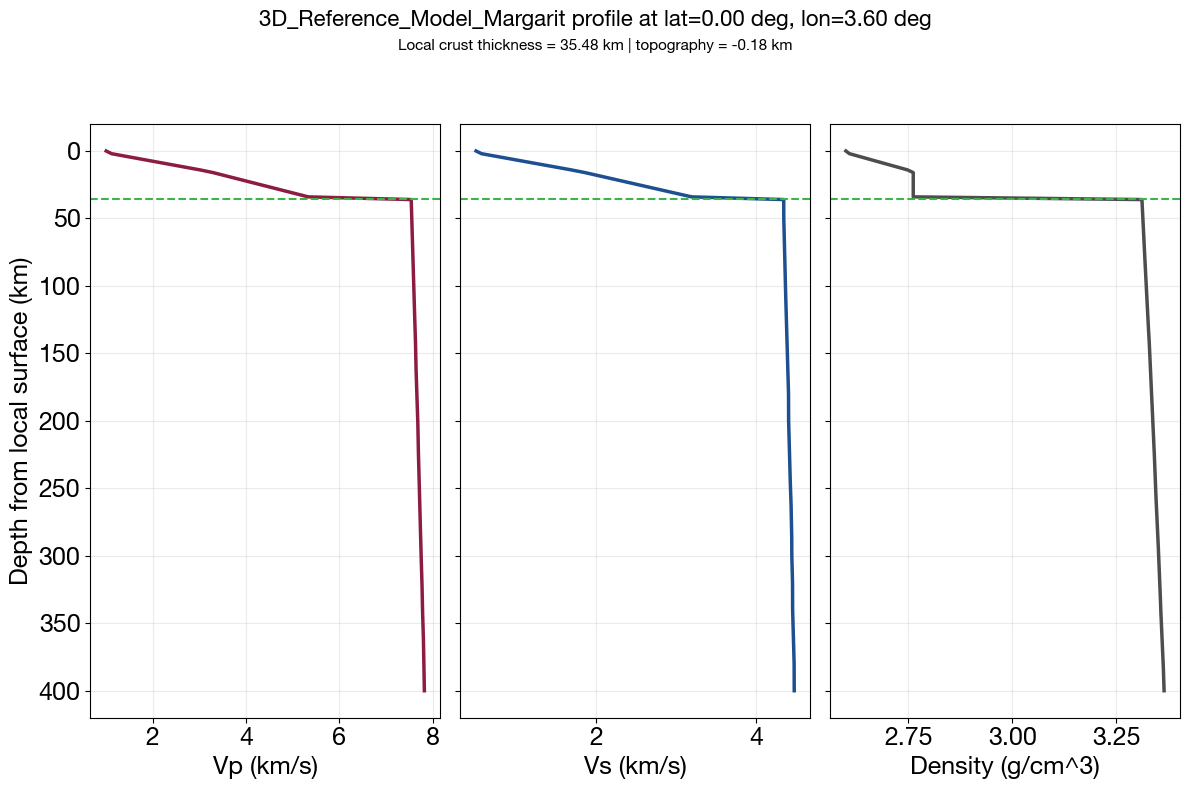

,lat_deg,lon_deg,depth_from_surface_km,radius_km,distance_below_moho_km,region,vp_km_s,vs_km_s,rho_g_cm3,surface_radius_km,crust_thickness_km,moho_radius_km,reference_crust_depth_km,reference_mantle_depth_km
0,0.0,3.6,0.0,1737.221,0.0,crust,1.000,0.500,2.600,1737.221,35.479,1701.742,0.000,28.0
1,0.0,3.6,2.0,1735.221,0.0,crust,1.116,0.568,2.609,1737.221,35.479,1701.742,1.578,28.0
2,0.0,3.6,4.0,1733.221,0.0,crust,1.431,0.755,2.632,1737.221,35.479,1701.742,3.157,28.0
3,0.0,3.6,6.0,1731.221,0.0,crust,1.747,0.941,2.655,1737.221,35.479,1701.742,4.735,28.0
4,0.0,3.6,8.0,1729.221,0.0,crust,2.063,1.128,2.678,1737.221,35.479,1701.742,6.314,28.0
5,0.0,3.6,10.0,1727.221,0.0,crust,2.378,1.315,2.702,1737.221,35.479,1701.742,7.892,28.0
6,0.0,3.6,12.0,1725.221,0.0,crust,2.694,1.501,2.725,1737.221,35.479,1701.742,9.470,28.0
7,0.0,3.6,14.0,1723.221,0.0,crust,3.010,1.688,2.748,1737.221,35.479,1701.742,11.049,28.0
8,0.0,3.6,16.0,1721.221,0.0,crust,3.290,1.859,2.762,1737.221,35.479,1701.742,12.627,28.0
9,0.0,3.6,18.0,1719.221,0.0,crust,3.517,2.007,2.762,1737.221,35.479,1701.742,14.206,28.0


In [50]:
PROFILE_LAT_DEG = 0.0
PROFILE_LON_DEG = CROSS_SECTION_LON_DEG
PROFILE_DEPTH_MAX_KM = 400.0
PROFILE_DEPTH_STEP_KM = 2.0

profile_depths_km = np.arange(0.0, PROFILE_DEPTH_MAX_KM + PROFILE_DEPTH_STEP_KM, PROFILE_DEPTH_STEP_KM)
profile_geometry = Reference_Model_Margarit_3D["sample_geometry"](PROFILE_LAT_DEG, PROFILE_LON_DEG)
profile_df = Reference_Model_Margarit_3D["sample_reference_profile"](
    lat_deg=PROFILE_LAT_DEG,
    lon_deg=PROFILE_LON_DEG,
    depth_grid_km=profile_depths_km,
)

fig, axes = plt.subplots(1, 3, figsize=(12, 8), sharey=True)
fig.patch.set_facecolor("white")

style = [
    ("vp_km_s", "Vp (km/s)", "#8c1d40"),
    ("vs_km_s", "Vs (km/s)", "#1d4f91"),
    ("rho_g_cm3", "Density (g/cm^3)", "#4d4d4d"),
]

for ax, (col, xlabel, color) in zip(axes, style):
    ax.plot(profile_df[col], profile_df["depth_from_surface_km"], color=color, lw=2.5)
    ax.axhline(profile_geometry["crust_thickness_km"], color="#3cb44b", ls="--", lw=1.5)
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.25)
    ax.set_facecolor("white")

axes[0].set_ylabel("Depth from local surface (km)")
axes[0].invert_yaxis()

fig.suptitle(
    f"3D_Reference_Model_Margarit profile at lat={PROFILE_LAT_DEG:.2f} deg, lon={PROFILE_LON_DEG:.2f} deg",
    fontsize=16,
)
fig.text(
    0.5,
    0.93,
    f"Local crust thickness = {profile_geometry['crust_thickness_km']:.2f} km | topography = {profile_geometry['topography_km']:.2f} km",
    ha="center",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

display(profile_df.head(12).round(3))


## Crust plots

The full grid is kept for sampling and export. The preview plots are downsampled for speed.


In [51]:
# crust_plot_3d = grail_crust_km.isel(lat=slice(None, None, PLOT_STRIDE_3D), lon=slice(None, None, PLOT_STRIDE_3D))
# lat = crust_plot_3d["lat"].values.astype(float)
# lon = crust_plot_3d["lon"].values.astype(float)
# lon360 = np.mod(lon, 360.0)
# order = np.argsort(lon360)
# lon360 = lon360[order]
# crust_values = crust_plot_3d.isel(lon=order).values.astype(float)

# lon2d, lat2d = np.meshgrid(np.deg2rad(lon360), np.deg2rad(lat))
# mean_thickness = np.nanmean(crust_values)
# radius = 1.0 + 0.02 * (crust_values - mean_thickness) / max(mean_thickness, 1.0)

# x = radius * np.cos(lat2d) * np.cos(lon2d)
# y = radius * np.cos(lat2d) * np.sin(lon2d)
# z = radius * np.sin(lat2d)

# norm = plt.Normalize(np.nanmin(crust_values), np.nanmax(crust_values))
# colors = plt.cm.viridis(norm(crust_values))

# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(111, projection="3d")
# ax.plot_surface(x, y, z, facecolors=colors, linewidth=0, antialiased=False, shade=False)
# ax.set_box_aspect((1, 1, 1))
# ax.set_axis_off()
# ax.set_title(f"GRAIL crustal thickness on a 3D Moon (stride={PLOT_STRIDE_3D})")

# mappable = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
# mappable.set_array([])
# cbar = fig.colorbar(mappable, ax=ax, shrink=0.7, pad=0.02)
# cbar.set_label("crust thickness (km)")
# plt.show()


In [52]:
# crust_plot_2d = grail_crust_km.isel(lat=slice(None, None, PLOT_STRIDE_2D), lon=slice(None, None, PLOT_STRIDE_2D))

# fig, ax = plt.subplots(figsize=(12, 5), facecolor="white")
# image = ax.imshow(
#     crust_plot_2d.values,
#     extent=[0, 360, -90, 90],
#     origin="lower",
#     aspect="auto",
#     interpolation="nearest",
#     cmap="viridis",
# )
# ax.set_title(f"GRAIL crustal thickness map (stride={PLOT_STRIDE_2D})")
# ax.set_xlabel("longitude (deg)")
# ax.set_ylabel("latitude (deg)")
# cbar = fig.colorbar(image, ax=ax, pad=0.02)
# cbar.set_label("crust thickness (km)")
# plt.tight_layout()
# plt.show()


## Full table and point checks


In [53]:
crust_table = grail_crust_km.to_dataframe(name="crust_thickness_km").reset_index()
crust_table["lon_360_deg"] = np.mod(crust_table["lon"].astype(float), 360.0)
crust_table["moho_radius_km"] = SURFACE_RADIUS_KM - crust_table["crust_thickness_km"]
crust_table = crust_table.rename(columns={"lat": "lat_deg", "lon": "lon_deg"})
crust_table = crust_table[["lat_deg", "lon_deg", "lon_360_deg", "crust_thickness_km", "moho_radius_km"]]
crust_table = crust_table.sort_values(["lat_deg", "lon_360_deg"]).reset_index(drop=True)

OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
crust_table.to_csv(OUTPUT_CSV, index=False)

display(crust_table.head(20))
print(f"Saved full crust table to: {OUTPUT_CSV}")
print(f"Number of grid points: {len(crust_table)}")


,lat_deg,lon_deg,lon_360_deg,crust_thickness_km,moho_radius_km
0,-90.0,0.000000,0.000000,35.022965,1702.377035
1,-90.0,360.000000,0.000000,35.022965,1702.377035
2,-90.0,0.099889,0.099889,35.022965,1702.377035
3,-90.0,0.199778,0.199778,35.022965,1702.377035
4,-90.0,0.299667,0.299667,35.022965,1702.377035
5,-90.0,0.399556,0.399556,35.022965,1702.377035
6,-90.0,0.499445,0.499445,35.022965,1702.377035
7,-90.0,0.599334,0.599334,35.022965,1702.377035
8,-90.0,0.699223,0.699223,35.022965,1702.377035
9,-90.0,0.799112,0.799112,35.022965,1702.377035


Saved full crust table to: /Users/ramonmargarit/IPGP Dropbox/Ramon Margarit/PhD/Science/Modelling_Envelopes/notebooks/results/grail_crust_thickness_table.csv
Number of grid points: 6499815


In [54]:
check_points = pd.DataFrame(
    {
        "name": ["Apollo 14", "Apollo 15", "Apollo 16"],
        "lat_deg": [-3.6440, 26.1322, -8.9730],
        "lon_deg": [-17.4775, 3.6339, 15.5000],
    }
)

sampled = check_points.copy()
sampled["lon_query_deg"] = [_match_longitude(grail_crust_km["lon"].values, lon) for lon in sampled["lon_deg"]]
sampled["crust_thickness_km"] = [
    sample_grid_along_longitude(grail_crust_km, [row.lat_deg], row.lon_query_deg)[0][0]
    for row in sampled.itertuples(index=False)
]
sampled["topography_km"] = [
    sample_grid_along_longitude(moon_topography_m, [row.lat_deg], row.lon_query_deg)[0][0] / 1e3
    for row in sampled.itertuples(index=False)
]
sampled["surface_radius_km"] = SURFACE_RADIUS_KM + sampled["topography_km"]
sampled["moho_radius_km"] = sampled["surface_radius_km"] - sampled["crust_thickness_km"]
display(sampled)


,name,lat_deg,lon_deg,lon_query_deg,crust_thickness_km,topography_km,surface_radius_km,moho_radius_km
0,Apollo 14,-3.6440,-17.4775,342.5225,33.299164,-1.034677,1736.365323,1703.066160
1,Apollo 15,26.1322,3.6339,3.6339,31.435010,-1.895155,1735.504845,1704.069835
2,Apollo 16,-8.9730,15.5000,15.5000,38.629965,0.045734,1737.445734,1698.815769


## Longitude cross-section with topography

The outer boundary is sampled from `load_moon_relief` at the selected longitude and its antipode. The dashed line is the true Moho. The solid line and filled crust are exaggerated for visibility.


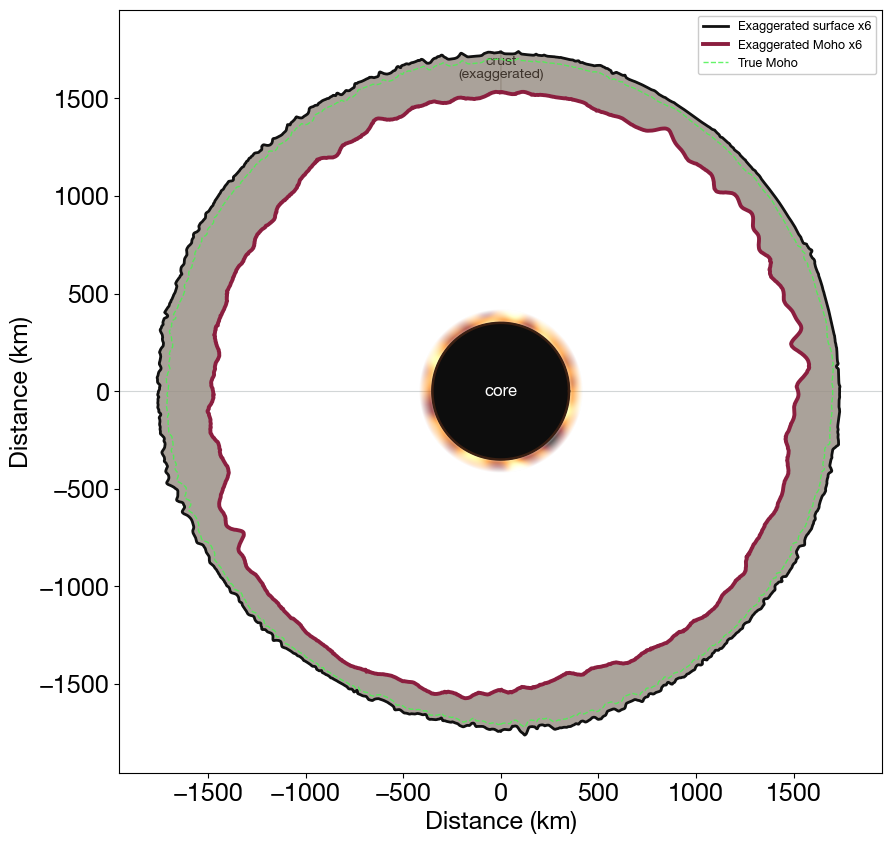

In [55]:
latitudes = np.sort(grail_crust_km["lat"].values.astype(float))

crust_near_km, lon_near = sample_grid_along_longitude(grail_crust_km, latitudes, CROSS_SECTION_LON_DEG)
crust_far_km, lon_far = sample_grid_along_longitude(grail_crust_km, latitudes, CROSS_SECTION_LON_DEG + 180.0)

topo_near_km, _ = sample_grid_along_longitude(moon_topography_m, latitudes, lon_near)
topo_far_km, _ = sample_grid_along_longitude(moon_topography_m, latitudes, lon_far)
topo_near_km = topo_near_km / 1e3
topo_far_km = topo_far_km / 1e3

surface_near_km = SURFACE_RADIUS_KM + TOPOGRAPHY_EXAGGERATION * topo_near_km
surface_far_km = SURFACE_RADIUS_KM + TOPOGRAPHY_EXAGGERATION * topo_far_km

moho_near_km = surface_near_km - crust_near_km
moho_far_km = surface_far_km - crust_far_km
moho_near_ex_km = np.maximum(CORE_RADIUS_KM * 1.05, surface_near_km - MOHO_EXAGGERATION * crust_near_km)
moho_far_ex_km = np.maximum(CORE_RADIUS_KM * 1.05, surface_far_km - MOHO_EXAGGERATION * crust_far_km)

lat_rad = np.deg2rad(latitudes)
x_surface_near = surface_near_km * np.cos(lat_rad)
z_surface_near = surface_near_km * np.sin(lat_rad)
x_surface_far = -surface_far_km * np.cos(lat_rad)
z_surface_far = surface_far_km * np.sin(lat_rad)

x_moho_near = moho_near_km * np.cos(lat_rad)
z_moho_near = moho_near_km * np.sin(lat_rad)
x_moho_far = -moho_far_km * np.cos(lat_rad)
z_moho_far = moho_far_km * np.sin(lat_rad)

x_moho_near_ex = moho_near_ex_km * np.cos(lat_rad)
z_moho_near_ex = moho_near_ex_km * np.sin(lat_rad)
x_moho_far_ex = -moho_far_ex_km * np.cos(lat_rad)
z_moho_far_ex = moho_far_ex_km * np.sin(lat_rad)

x_crust_poly = np.concatenate([x_surface_near, x_moho_near_ex[::-1], x_moho_far_ex, x_surface_far[::-1]])
z_crust_poly = np.concatenate([z_surface_near, z_moho_near_ex[::-1], z_moho_far_ex, z_surface_far[::-1]])

theta = np.linspace(0.0, 2.0 * np.pi, 721)
x_core_circle = CORE_RADIUS_KM * np.cos(theta)
z_core_circle = CORE_RADIUS_KM * np.sin(theta)

crust_color = "#988e84"
moho_color = "#8b1e3f"
true_moho_color = "#49f34f"

fig, ax = plt.subplots(figsize=(9, 9), facecolor="white")
ax.set_facecolor("white")

core_inner = CORE_RADIUS_KM * MAGMA_INNER_FACTOR
core_outer = CORE_RADIUS_KM * MAGMA_OUTER_FACTOR
magma_x = np.linspace(-core_outer, core_outer, MAGMA_PIXELS)
magma_y = np.linspace(-core_outer, core_outer, MAGMA_PIXELS)
magma_X, magma_Y = np.meshgrid(magma_x, magma_y)
magma_R = np.sqrt(magma_X**2 + magma_Y**2)
magma_mask = (magma_R >= core_inner) & (magma_R <= core_outer)

rng = np.random.default_rng(MAGMA_RANDOM_SEED)
noise = rng.random((MAGMA_PIXELS, MAGMA_PIXELS))
try:
    from scipy.ndimage import gaussian_filter
    noise = gaussian_filter(noise, sigma=20)
except ModuleNotFoundError:
    pass

magma_field = np.where(magma_mask, noise, np.nan)
d_to_inner = magma_R - core_inner
d_to_outer = core_outer - magma_R
d = np.minimum(d_to_inner, d_to_outer)
alpha_ring = np.clip(d / MAGMA_FADE_KM, 0.0, 1.0)
alpha_ring[~magma_mask] = 0.0

ax.imshow(
    magma_field,
    extent=[-core_outer, core_outer, -core_outer, core_outer],
    origin="lower",
    cmap="afmhot",
    alpha=alpha_ring,
    zorder=2,
)
ax.fill(x_core_circle, z_core_circle, color="0.05", alpha=1.0, zorder=3)

ax.fill(x_crust_poly, z_crust_poly, color=crust_color, alpha=0.82, zorder=3)
ax.plot(x_surface_near, z_surface_near, color="#111111", lw=2.0, zorder=5, label=f"Exaggerated surface x{TOPOGRAPHY_EXAGGERATION:.0f}")
ax.plot(x_surface_far, z_surface_far, color="#111111", lw=2.0, zorder=5)
ax.plot(x_core_circle, z_core_circle, color="#3a1f12", lw=1.8, zorder=6)
ax.plot(x_moho_near_ex, z_moho_near_ex, color=moho_color, lw=2.8, zorder=7, label=f"Exaggerated Moho x{MOHO_EXAGGERATION:.0f}")
ax.plot(x_moho_far_ex, z_moho_far_ex, color=moho_color, lw=2.8, zorder=7)
ax.plot(x_moho_near, z_moho_near, color=true_moho_color, lw=1.0, ls="--", alpha=0.85, zorder=6, label="True Moho")
ax.plot(x_moho_far, z_moho_far, color=true_moho_color, lw=1.0, ls="--", alpha=0.85, zorder=6)

ax.axhline(0.0, color="#7f8c8d", lw=0.8, alpha=0.35, zorder=1)

# label_box = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="0.75", alpha=0.95)
# ax.text(
#     0.02,
#     0.98,
#     f"Selected longitude: {CROSS_SECTION_LON_DEG:.1f} deg\nTopography exaggerated x{TOPOGRAPHY_EXAGGERATION:.0f}\nMoho depth exaggerated x{MOHO_EXAGGERATION:.0f}",
#     transform=ax.transAxes,
#     va="top",
#     ha="left",
#     fontsize=10,
#     bbox=label_box,
# )

ax.text(0.0, 0.0, "core", ha="center", va="center", color="white", fontsize=12, weight="bold")
ax.text(0.0, np.nanmax(np.concatenate([surface_near_km, surface_far_km])) - 120.0, "crust\n(exaggerated)", ha="center", va="center", color="#3e342c", fontsize=10, weight="bold")

margin = 180.0
rmax = np.nanmax(np.concatenate([surface_near_km, surface_far_km]))
ax.set_xlim(-(rmax + margin), rmax + margin)
ax.set_ylim(-(rmax + margin), rmax + margin)
ax.set_aspect("equal")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Distance (km)")
# ax.set_title("Lunar longitude cross-section with topography, Moho, and core", fontsize=16, weight="bold")
ax.legend(loc="upper right", fontsize=9, frameon=True, facecolor="white", edgecolor="0.75")
plt.tight_layout()
plt.show()
